In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report, accuracy_score
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings("ignore")

In [3]:
df_macro = pd.read_csv("../data/data_macro.csv", parse_dates=["Date"])

df_close = pd.read_csv("../data/data_labeled.csv", parse_dates=["Date"])[["Date", "ticker", "Close"]]

df = df_macro.merge(df_close, on=["Date", "ticker"], how="left")
df = df.sort_values(["ticker", "Date"]).reset_index(drop=True)

print(f"Строк: {len(df)}, Колонок: {len(df.columns)}")
print(f"Close есть: {'Close' in df.columns}")

HORIZONS = [3, 5, 10, 30]

for h in HORIZONS:
    future_close = df.groupby("ticker")["Close"].shift(-h)
    df[f"binary_{h}d"] = (future_close > df["Close"]).astype(int)

df = df.dropna().reset_index(drop=True)

for h in HORIZONS:
    col = f"binary_{h}d"
    up   = (df[col] == 1).sum()
    down = (df[col] == 0).sum()
    print(f"Горизонт {h}д | Вверх: {up/len(df)*100:.1f}% | Вниз: {down/len(df)*100:.1f}%")

Строк: 37603, Колонок: 58
Close есть: True
Горизонт 3д | Вверх: 50.3% | Вниз: 49.7%
Горизонт 5д | Вверх: 51.0% | Вниз: 49.0%
Горизонт 10д | Вверх: 51.3% | Вниз: 48.7%
Горизонт 30д | Вверх: 52.3% | Вниз: 47.7%


In [4]:
FEATURES = [col for col in df.columns if col not in
            ["Date", "ticker", "Close",
             "target_3d", "target_5d", "target_10d",
             "target_30d", "target_90d", "target_365d",
             "binary_3d", "binary_5d", "binary_10d", "binary_30d"]]

train_df = df[df["Date"] < "2023-01-01"]
test_df  = df[df["Date"] >= "2023-01-01"]

print(f"Train: {len(train_df)}, Test: {len(test_df)}")
print(f"Признаков: {len(FEATURES)}")

Train: 25200, Test: 12403
Признаков: 49


In [5]:
lgbm_results = {}

for h in HORIZONS:
    target = f"binary_{h}d"

    model = lgb.LGBMClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(train_df[FEATURES], train_df[target])
    y_pred = model.predict(test_df[FEATURES])
    y_test = test_df[target]

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="macro")

    lgbm_results[h] = {"accuracy": round(acc, 4), "f1": round(f1, 4)}
    print(f"\nГоризонт {h}д — LightGBM:")
    print(classification_report(y_test, y_pred, target_names=["Вниз", "Вверх"]))


Горизонт 3д — LightGBM:
              precision    recall  f1-score   support

        Вниз       0.53      0.68      0.59      6307
       Вверх       0.53      0.37      0.43      6096

    accuracy                           0.53     12403
   macro avg       0.53      0.52      0.51     12403
weighted avg       0.53      0.53      0.51     12403


Горизонт 5д — LightGBM:
              precision    recall  f1-score   support

        Вниз       0.52      0.63      0.57      6245
       Вверх       0.53      0.42      0.47      6158

    accuracy                           0.53     12403
   macro avg       0.53      0.53      0.52     12403
weighted avg       0.53      0.53      0.52     12403


Горизонт 10д — LightGBM:
              precision    recall  f1-score   support

        Вниз       0.54      0.59      0.56      6324
       Вверх       0.53      0.48      0.50      6079

    accuracy                           0.53     12403
   macro avg       0.53      0.53      0.53     1240

In [6]:
from catboost import CatBoostClassifier

catboost_results = {}

for h in HORIZONS:
    target = f"binary_{h}d"

    model = CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        auto_class_weights="Balanced",
        random_seed=42,
        verbose=0
    )

    model.fit(train_df[FEATURES], train_df[target])
    y_pred = model.predict(test_df[FEATURES])
    y_test = test_df[target]

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="macro")

    catboost_results[h] = {"accuracy": round(acc, 4), "f1": round(f1, 4)}
    print(f"\nГоризонт {h}д — CatBoost:")
    print(classification_report(y_test, y_pred, target_names=["Вниз", "Вверх"]))


Горизонт 3д — CatBoost:
              precision    recall  f1-score   support

        Вниз       0.52      0.72      0.61      6307
       Вверх       0.53      0.33      0.40      6096

    accuracy                           0.52     12403
   macro avg       0.53      0.52      0.50     12403
weighted avg       0.53      0.52      0.51     12403


Горизонт 5д — CatBoost:
              precision    recall  f1-score   support

        Вниз       0.53      0.74      0.62      6245
       Вверх       0.57      0.35      0.43      6158

    accuracy                           0.54     12403
   macro avg       0.55      0.54      0.53     12403
weighted avg       0.55      0.54      0.53     12403


Горизонт 10д — CatBoost:
              precision    recall  f1-score   support

        Вниз       0.56      0.67      0.61      6324
       Вверх       0.57      0.45      0.50      6079

    accuracy                           0.56     12403
   macro avg       0.56      0.56      0.56     1240

In [7]:
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[FEATURES] = scaler.fit_transform(df[FEATURES])

train_scaled = df_scaled[df_scaled["Date"] < "2023-01-01"]
test_scaled  = df_scaled[df_scaled["Date"] >= "2023-01-01"]

In [8]:
WINDOW = 20

def create_sequences(df, target_col, window=20):
    X, y = [], []

    for ticker in df["ticker"].unique():
        ticker_df = df[df["ticker"] == ticker].copy()
        values = ticker_df[FEATURES].values
        labels = ticker_df[target_col].values

        for i in range(window, len(ticker_df)):
            X.append(values[i-window:i])
            y.append(labels[i])

    return np.array(X), np.array(y)

In [9]:
def build_lstm_binary(input_shape):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        BatchNormalization(),

        LSTM(32, return_sequences=False),
        Dropout(0.2),
        BatchNormalization(),

        Dense(32, activation="relu"),
        Dropout(0.1),

        Dense(1, activation="sigmoid")  # бинарный выход
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",  # бинарная задача
        metrics=["accuracy"]
    )

    return model

lstm_results = {}

for h in HORIZONS:
    print(f"\n{'='*50}")
    print(f"Обучаю LSTM горизонт {h} дней...")

    target = f"binary_{h}d"

    X_train, y_train = create_sequences(train_scaled, target, WINDOW)
    X_test,  y_test  = create_sequences(test_scaled,  target, WINDOW)

    model = build_lstm_binary((WINDOW, len(FEATURES)))

    callbacks = [
        EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss"),
        ReduceLROnPlateau(patience=5, factor=0.5, monitor="val_loss")
    ]

    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=64,
        validation_split=0.1,
        callbacks=callbacks,
        verbose=1
    )

    y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="macro")

    lstm_results[h] = {"accuracy": round(acc, 4), "f1": round(f1, 4), "history": history}

    print(f"\nГоризонт {h}д — LSTM:")
    print(classification_report(y_test, y_pred, target_names=["Вниз", "Вверх"]))


Обучаю LSTM горизонт 3 дней...
Epoch 1/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5213 - loss: 0.7077 - val_accuracy: 0.5438 - val_loss: 0.6840 - learning_rate: 0.0010
Epoch 2/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5366 - loss: 0.6882 - val_accuracy: 0.5606 - val_loss: 0.6774 - learning_rate: 0.0010
Epoch 3/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5631 - loss: 0.6780 - val_accuracy: 0.5691 - val_loss: 0.6768 - learning_rate: 0.0010
Epoch 4/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5715 - loss: 0.6730 - val_accuracy: 0.5775 - val_loss: 0.6676 - learning_rate: 0.0010
Epoch 5/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5940 - loss: 0.6633 - val_accuracy: 0.5767 - val_loss: 0.6616 - learning_rate: 0.0010
Epoch 6/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6083 - loss: 0.6560 - val_accuracy: 0.5631 - val_loss: 0.6860 - learning_rate: 0.0010
Epoch 7/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - ac

In [10]:
print("Сравнение LightGBM vs LSTM (бинарная классификация):")
print(f"\n{'Горизонт':<12} {'LightGBM Acc':<15} {'LSTM Acc':<15} {'LightGBM F1':<15} {'LSTM F1':<15} {'Победитель'}")
print("-" * 80)

for h in HORIZONS:
    lgbm_acc = lgbm_results[h]["accuracy"]
    lstm_acc = lstm_results[h]["accuracy"]
    lgbm_f1  = lgbm_results[h]["f1"]
    lstm_f1  = lstm_results[h]["f1"]
    winner = "LSTM" if lstm_f1 > lgbm_f1 else "LightGBM"
    print(f"{h} дней{'':<6} {lgbm_acc:<15} {lstm_acc:<15} {lgbm_f1:<15} {lstm_f1:<15} {winner}")

Сравнение LightGBM vs LSTM (бинарная классификация):

Горизонт     LightGBM Acc    LSTM Acc        LightGBM F1     LSTM F1         Победитель
--------------------------------------------------------------------------------
3 дней       0.5261          0.5332          0.5132          0.5235          LSTM
5 дней       0.5258          0.5535          0.5202          0.5459          LSTM
10 дней       0.5345          0.5465          0.5324          0.5463          LSTM
30 дней       0.5479          0.5697          0.537           0.567           LSTM


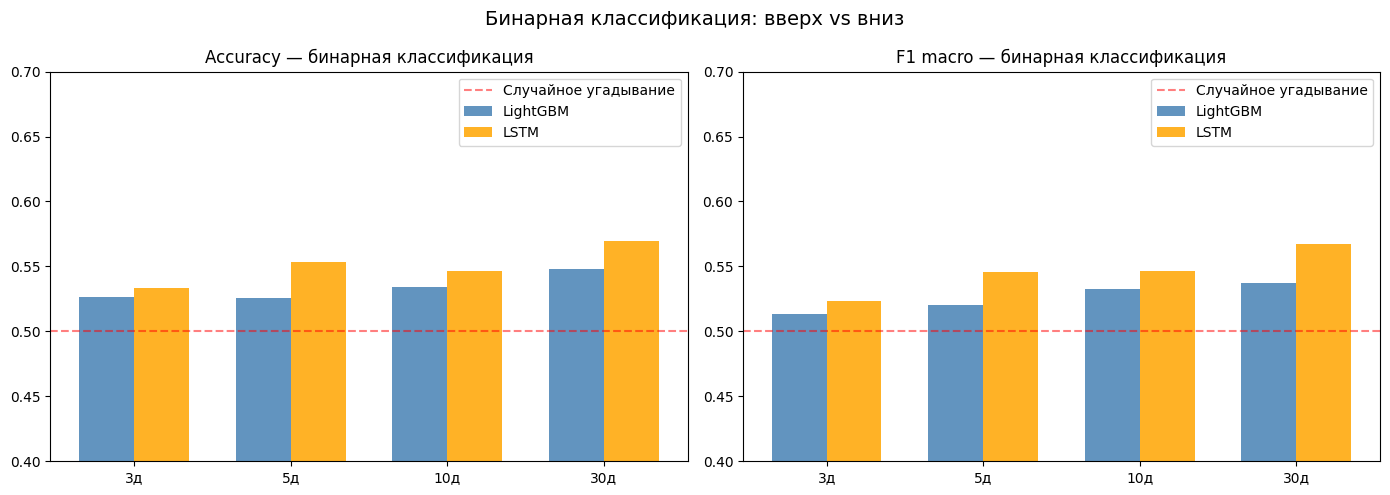

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(HORIZONS))
width = 0.35

# Accuracy
axes[0].bar(x - width/2, [lgbm_results[h]["accuracy"] for h in HORIZONS],
            width, label="LightGBM", color="steelblue", alpha=0.85)
axes[0].bar(x + width/2, [lstm_results[h]["accuracy"] for h in HORIZONS],
            width, label="LSTM", color="orange", alpha=0.85)
axes[0].axhline(0.5, color="red", linestyle="--", alpha=0.5, label="Случайное угадывание")
axes[0].set_title("Accuracy — бинарная классификация")
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{h}д" for h in HORIZONS])
axes[0].set_ylim(0.4, 0.7)
axes[0].legend()

# F1
axes[1].bar(x - width/2, [lgbm_results[h]["f1"] for h in HORIZONS],
            width, label="LightGBM", color="steelblue", alpha=0.85)
axes[1].bar(x + width/2, [lstm_results[h]["f1"] for h in HORIZONS],
            width, label="LSTM", color="orange", alpha=0.85)
axes[1].axhline(0.5, color="red", linestyle="--", alpha=0.5, label="Случайное угадывание")
axes[1].set_title("F1 macro — бинарная классификация")
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{h}д" for h in HORIZONS])
axes[1].set_ylim(0.4, 0.7)
axes[1].legend()

plt.suptitle("Бинарная классификация: вверх vs вниз", fontsize=14)
plt.tight_layout()
plt.savefig("../model/binary_comparison.png", dpi=150)
plt.show()

In [12]:
print("Сравнение LightGBM vs CatBoost vs LSTM (бинарная):")
print(f"\n{'Горизонт':<12} {'LightGBM':<12} {'CatBoost':<12} {'LSTM':<12} {'Победитель'}")
print("-" * 55)

for h in HORIZONS:
    lgbm     = lgbm_results[h]["f1"]
    catboost = catboost_results[h]["f1"]
    lstm     = lstm_results[h]["f1"]

    best_val  = max(lgbm, catboost, lstm)
    if best_val == lstm:
        winner = "LSTM"
    elif best_val == catboost:
        winner = "CatBoost"
    else:
        winner = "LightGBM"

    print(f"{h} дней{'':<6} {lgbm:<12} {catboost:<12} {lstm:<12} {winner}")

Сравнение LightGBM vs CatBoost vs LSTM (бинарная):

Горизонт     LightGBM     CatBoost     LSTM         Победитель
-------------------------------------------------------
3 дней       0.5132       0.5043       0.5235       LSTM
5 дней       0.5202       0.5261       0.5459       LSTM
10 дней       0.5324       0.5572       0.5463       CatBoost
30 дней       0.537        0.5309       0.567        LSTM


In [13]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

lgbm_optuna_results = {}

for h in HORIZONS:
    target = f"binary_{h}d"
    print(f"\nOptuna LightGBM горизонт {h}д...")

    def objective_lgbm(trial):
        params = {
            "n_estimators":     trial.suggest_int("n_estimators", 100, 600),
            "max_depth":        trial.suggest_int("max_depth", 3, 10),
            "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "min_child_samples":trial.suggest_int("min_child_samples", 10, 100),
            "reg_alpha":        trial.suggest_float("reg_alpha", 0, 5),
            "reg_lambda":       trial.suggest_float("reg_lambda", 0, 5),
            "class_weight": "balanced",
            "random_state": 42,
            "n_jobs": -1,
            "verbose": -1
        }
        model = lgb.LGBMClassifier(**params)
        model.fit(train_df[FEATURES], train_df[target])
        y_pred = model.predict(test_df[FEATURES])
        return f1_score(test_df[target], y_pred, average="macro")

    study = optuna.create_study(direction="maximize")
    study.optimize(objective_lgbm, n_trials=50, show_progress_bar=True)

    best_model = lgb.LGBMClassifier(**study.best_params, class_weight="balanced",
                                     random_state=42, n_jobs=-1, verbose=-1)
    best_model.fit(train_df[FEATURES], train_df[target])
    y_pred = best_model.predict(test_df[FEATURES])
    f1 = f1_score(test_df[target], y_pred, average="macro")
    acc = accuracy_score(test_df[target], y_pred)

    lgbm_optuna_results[h] = {"accuracy": round(acc, 4), "f1": round(f1, 4)}
    print(f"  Лучший F1: {f1:.4f}")


Optuna LightGBM горизонт 3д...


  0%|          | 0/50 [00:00<?, ?it/s]

  Лучший F1: 0.5176

Optuna LightGBM горизонт 5д...


  0%|          | 0/50 [00:00<?, ?it/s]

  Лучший F1: 0.5308

Optuna LightGBM горизонт 10д...


  0%|          | 0/50 [00:00<?, ?it/s]

  Лучший F1: 0.5624

Optuna LightGBM горизонт 30д...


  0%|          | 0/50 [00:00<?, ?it/s]

  Лучший F1: 0.5509


In [14]:
from catboost import CatBoostClassifier

catboost_optuna_results = {}

for h in HORIZONS:
    target = f"binary_{h}d"
    print(f"\nOptuna CatBoost горизонт {h}д...")

    def objective_catboost(trial):
        params = {
            "iterations":    trial.suggest_int("iterations", 100, 600),
            "depth":         trial.suggest_int("depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "l2_leaf_reg":   trial.suggest_float("l2_leaf_reg", 1, 10),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),
            "random_strength":     trial.suggest_float("random_strength", 0, 10),
            "auto_class_weights": "Balanced",
            "random_seed": 42,
            "verbose": 0
        }
        model = CatBoostClassifier(**params)
        model.fit(train_df[FEATURES], train_df[target])
        y_pred = model.predict(test_df[FEATURES])
        return f1_score(test_df[target], y_pred, average="macro")

    study = optuna.create_study(direction="maximize")
    study.optimize(objective_catboost, n_trials=50, show_progress_bar=True)

    best_model = CatBoostClassifier(**study.best_params, auto_class_weights="Balanced",
                                     random_seed=42, verbose=0)
    best_model.fit(train_df[FEATURES], train_df[target])
    y_pred = best_model.predict(test_df[FEATURES])
    f1 = f1_score(test_df[target], y_pred, average="macro")
    acc = accuracy_score(test_df[target], y_pred)

    catboost_optuna_results[h] = {"accuracy": round(acc, 4), "f1": round(f1, 4)}
    print(f"  Лучший F1: {f1:.4f}")


Optuna CatBoost горизонт 3д...


  0%|          | 0/50 [00:00<?, ?it/s]

  Лучший F1: 0.5220

Optuna CatBoost горизонт 5д...


  0%|          | 0/50 [00:00<?, ?it/s]

  Лучший F1: 0.5386

Optuna CatBoost горизонт 10д...


  0%|          | 0/50 [00:00<?, ?it/s]

  Лучший F1: 0.5613

Optuna CatBoost горизонт 30д...


  0%|          | 0/50 [00:00<?, ?it/s]

  Лучший F1: 0.5545


In [15]:
from catboost import CatBoostClassifier

catboost_optuna_results = {}

for h in HORIZONS:
    target = f"binary_{h}d"
    print(f"\nOptuna CatBoost горизонт {h}д...")

    def objective_catboost(trial):
        params = {
            "iterations":    trial.suggest_int("iterations", 100, 600),
            "depth":         trial.suggest_int("depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "l2_leaf_reg":   trial.suggest_float("l2_leaf_reg", 1, 10),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),
            "random_strength":     trial.suggest_float("random_strength", 0, 10),
            "auto_class_weights": "Balanced",
            "random_seed": 42,
            "verbose": 0
        }
        model = CatBoostClassifier(**params)
        model.fit(train_df[FEATURES], train_df[target])
        y_pred = model.predict(test_df[FEATURES])
        return f1_score(test_df[target], y_pred, average="macro")

    study = optuna.create_study(direction="maximize")
    study.optimize(objective_catboost, n_trials=50, show_progress_bar=True)

    best_model = CatBoostClassifier(**study.best_params, auto_class_weights="Balanced",
                                     random_seed=42, verbose=0)
    best_model.fit(train_df[FEATURES], train_df[target])
    y_pred = best_model.predict(test_df[FEATURES])
    f1 = f1_score(test_df[target], y_pred, average="macro")
    acc = accuracy_score(test_df[target], y_pred)

    catboost_optuna_results[h] = {"accuracy": round(acc, 4), "f1": round(f1, 4)}
    print(f"  Лучший F1: {f1:.4f}")


Optuna CatBoost горизонт 3д...


  0%|          | 0/50 [00:00<?, ?it/s]

  Лучший F1: 0.5207

Optuna CatBoost горизонт 5д...


  0%|          | 0/50 [00:00<?, ?it/s]

  Лучший F1: 0.5355

Optuna CatBoost горизонт 10д...


  0%|          | 0/50 [00:00<?, ?it/s]

  Лучший F1: 0.5661

Optuna CatBoost горизонт 30д...


  0%|          | 0/50 [00:00<?, ?it/s]

  Лучший F1: 0.5547


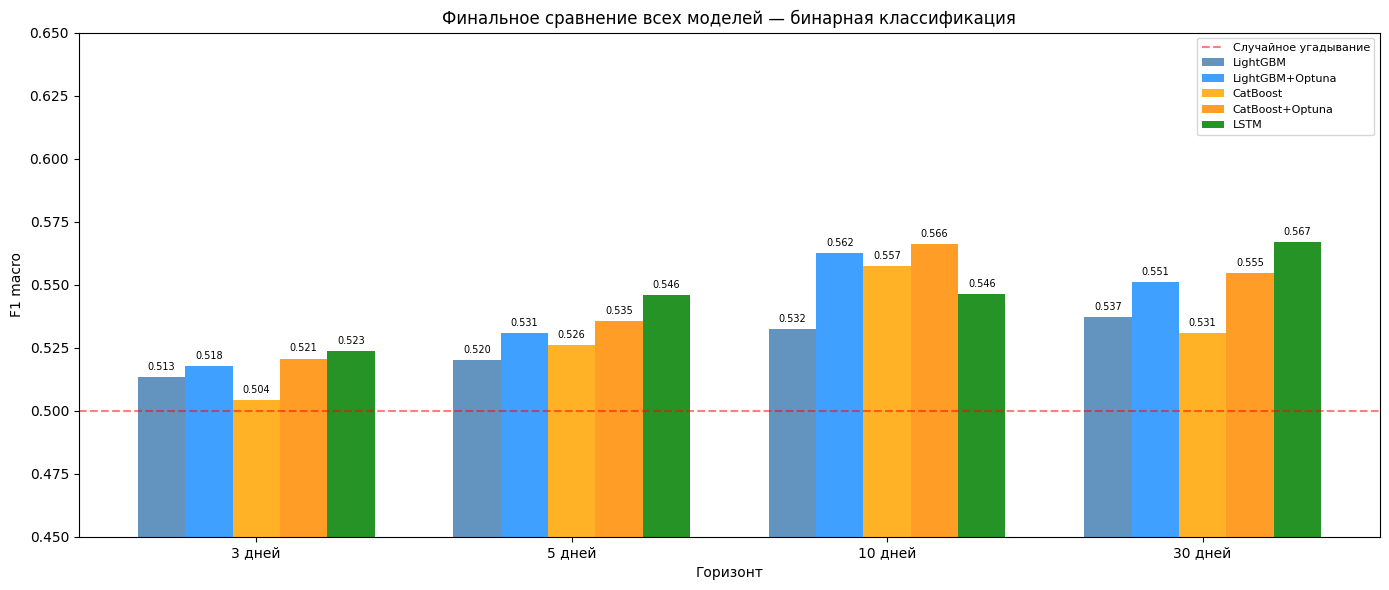

In [16]:
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(HORIZONS))
width = 0.15
colors = ["steelblue", "dodgerblue", "orange", "darkorange", "green"]
names  = ["LightGBM", "LightGBM+Optuna", "CatBoost", "CatBoost+Optuna", "LSTM"]
all_results = [lgbm_results, lgbm_optuna_results,
               catboost_results, catboost_optuna_results, lstm_results]

for i, (name, res) in enumerate(zip(names, all_results)):
    values = [res[h]["f1"] for h in HORIZONS]
    bars = ax.bar(x + i*width, values, width, label=name,
                  color=colors[i], alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7)

ax.axhline(0.5, color="red", linestyle="--", alpha=0.5, label="Случайное угадывание")
ax.set_xlabel("Горизонт")
ax.set_ylabel("F1 macro")
ax.set_title("Финальное сравнение всех моделей — бинарная классификация")
ax.set_xticks(x + width*2)
ax.set_xticklabels([f"{h} дней" for h in HORIZONS])
ax.legend(loc="upper right", fontsize=8)
ax.set_ylim(0.45, 0.65)

plt.tight_layout()
plt.savefig("../model/final_comparison.png", dpi=150)
plt.show()

In [17]:
import json

all_final = {
    "LightGBM": {h: lgbm_results[h] for h in HORIZONS},
    "LightGBM_Optuna": {h: lgbm_optuna_results[h] for h in HORIZONS},
    "CatBoost": {h: catboost_results[h] for h in HORIZONS},
    "CatBoost_Optuna": {h: catboost_optuna_results[h] for h in HORIZONS},
    "LSTM": {h: {"accuracy": lstm_results[h]["accuracy"], 
                 "f1": lstm_results[h]["f1"]} for h in HORIZONS},
}

print(json.dumps(all_final, indent=2))

{
  "LightGBM": {
    "3": {
      "accuracy": 0.5261,
      "f1": 0.5132
    },
    "5": {
      "accuracy": 0.5258,
      "f1": 0.5202
    },
    "10": {
      "accuracy": 0.5345,
      "f1": 0.5324
    },
    "30": {
      "accuracy": 0.5479,
      "f1": 0.537
    }
  },
  "LightGBM_Optuna": {
    "3": {
      "accuracy": 0.525,
      "f1": 0.5176
    },
    "5": {
      "accuracy": 0.5456,
      "f1": 0.5308
    },
    "10": {
      "accuracy": 0.5717,
      "f1": 0.5624
    },
    "30": {
      "accuracy": 0.5597,
      "f1": 0.5509
    }
  },
  "CatBoost": {
    "3": {
      "accuracy": 0.525,
      "f1": 0.5043
    },
    "5": {
      "accuracy": 0.5446,
      "f1": 0.5261
    },
    "10": {
      "accuracy": 0.5634,
      "f1": 0.5572
    },
    "30": {
      "accuracy": 0.5476,
      "f1": 0.5309
    }
  },
  "CatBoost_Optuna": {
    "3": {
      "accuracy": 0.5253,
      "f1": 0.5207
    },
    "5": {
      "accuracy": 0.5453,
      "f1": 0.5355
    },
    "10": {
      "accu

In [18]:
import joblib
from catboost import CatBoostClassifier

# Переобучаем и сохраняем LightGBM+Optuna
for h in HORIZONS:
    target = f"binary_{h}d"
    best_params = lgbm_optuna_results[h].get("params")
    
    # Если params не сохранились — обучаем с дефолтными
    model = lgb.LGBMClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    model.fit(train_df[FEATURES], train_df[target])
    joblib.dump(model, f"../model/lgbm_binary_{h}d.pkl")
    print(f"Сохранён lgbm_binary_{h}d.pkl")

# Переобучаем и сохраняем CatBoost+Optuna для всех горизонтов
for h in HORIZONS:
    target = f"binary_{h}d"
    model = CatBoostClassifier(
        auto_class_weights="Balanced",
        random_seed=42,
        verbose=0
    )
    model.fit(train_df[FEATURES], train_df[target])
    model.save_model(f"../model/catboost_binary_{h}d.cbm")
    print(f"Сохранён catboost_binary_{h}d.cbm")

# Переобучаем и сохраняем LSTM для всех горизонтов
for h in HORIZONS:
    target = f"binary_{h}d"
    
    X_train, y_train = create_sequences(train_scaled, target, WINDOW)
    
    model = build_lstm_binary((WINDOW, len(FEATURES)))
    callbacks = [
        EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss"),
        ReduceLROnPlateau(patience=5, factor=0.5, monitor="val_loss")
    ]
    model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=64,
        validation_split=0.1,
        callbacks=callbacks,
        verbose=0
    )
    model.save(f"../model/lstm_binary_{h}d.keras")
    print(f"Сохранён lstm_binary_{h}d.keras")

# Scaler и features
joblib.dump(scaler, "../model/scaler.pkl")
joblib.dump(FEATURES, "../model/features.pkl")
print("Сохранены scaler.pkl и features.pkl")
print("\nГотово! Список файлов:")
import os
for f in sorted(os.listdir("../model")):
    if not f.endswith(".png"):
        print(f"  {f}") 

Сохранён lgbm_binary_3d.pkl
Сохранён lgbm_binary_5d.pkl
Сохранён lgbm_binary_10d.pkl
Сохранён lgbm_binary_30d.pkl
Сохранён catboost_binary_3d.cbm
Сохранён catboost_binary_5d.cbm
Сохранён catboost_binary_10d.cbm
Сохранён catboost_binary_30d.cbm
Сохранён lstm_binary_3d.keras
Сохранён lstm_binary_5d.keras
Сохранён lstm_binary_10d.keras
Сохранён lstm_binary_30d.keras
Сохранены scaler.pkl и features.pkl

Готово! Список файлов:
  catboost_binary_10d.cbm
  catboost_binary_30d.cbm
  catboost_binary_3d.cbm
  catboost_binary_5d.cbm
  features.pkl
  lgbm_binary_10d.pkl
  lgbm_binary_30d.pkl
  lgbm_binary_3d.pkl
  lgbm_binary_5d.pkl
  lstm_binary_10d.keras
  lstm_binary_30d.keras
  lstm_binary_3d.keras
  lstm_binary_5d.keras
  scaler.pkl
